In [5]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20.0 , 10.0)

data = pd.read_csv('headbrain.csv')
print(data.shape)
data.head()

(237, 4)


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [6]:
X = data['Head Size(cm^3)'].values
Y = data['Brain Weight(grams)'].values

In [7]:
# mean of X and Y
mean_x = np.mean(X)
mean_y = np.mean(Y)

# Total number of values

m = len(X)

# using the formula to calculate b1 and b0
numer = 0
denom = 0
for i in range(m):
    numer += (X[i] - mean_x) * (Y[i] - mean_y)
    denom += (X[i] - mean_x) ** 2
b1 = numer / denom
b0 = mean_y - (b1 * mean_x)

print(b1, b0)


0.26342933948939945 325.57342104944223


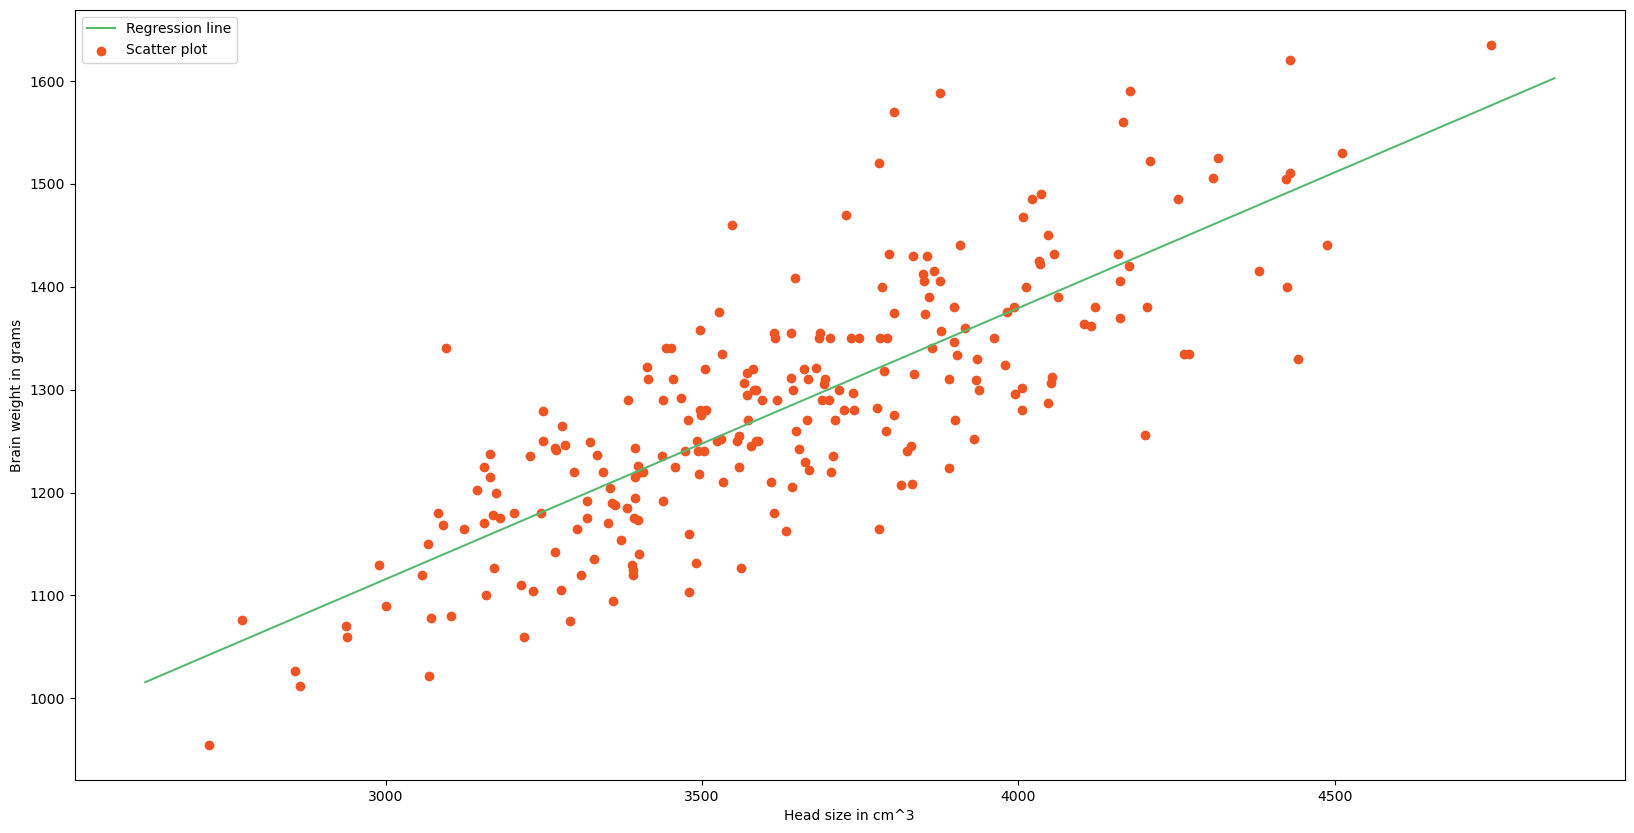

In [12]:
max_x = np.max(X) + 100
min_x = np.min(X) -100

# calculating line values x and y
x = np.linspace(min_x , max_x , 1000)
y = b0 + b1 * x

# ploting line
plt.plot(x , y , color='#58b970' , label='Regression line')
# plting scatter points
plt.scatter(X , Y , c='#ef5423' , label='Scatter plot')

plt.xlabel('Head size in cm^3')
plt.ylabel('Brain weight in grams')
plt.legend()
plt.show()

In [10]:
# the code used to calculate R^2
ss_t = 0
ss_r = 0
for i in range(m):
    y_pred = b0 + b1 * X[i]
    ss_t += (Y[i] - mean_y) ** 2
    ss_r += (Y[i] - y_pred) ** 2
r2 = 1 - (ss_r/ss_t)
print(r2)


0.6393117199570003


In [11]:
# implementing the linear regression model using sickit learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# cannot use rank 1 matrix in sickit learn
X = X.reshape((m, 1))

# creating model
reg = LinearRegression()
# fitting training data
reg = reg.fit(X, Y)
# Y prediction
Y_Pred = reg.predict(X)

# calculating R2 score
r2_score = reg.score(X, Y)
print(r2_score)

0.639311719957
